In [ ]:
# =========================
# IMPORTS
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================
# PATHS
# =========================
train_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/train"
val_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/val"
test_path = "/content/drive/MyDrive/Knee Osteoarthritis Classification/test"

IMG_SIZE = 300
BATCH_SIZE = 16

# =========================
# DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = val_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =========================
# MODEL
# =========================
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# =========================
# COMPILE (LABEL SMOOTHING)
# =========================
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

# =========================
# CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

# =========================
# TEST
# =========================
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)

Found 3780 images belonging to 3 classes.
Found 1080 images belonging to 3 classes.
Found 540 images belonging to 3 classes.
Epoch 1/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 323s 850ms/step - accuracy: 0.4381 - loss: 1.3347 - val_accuracy: 0.5241 - val_loss: 0.9998 - learning_rate: 1.0000e-04
Epoch 2/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 119s 500ms/step - accuracy: 0.5296 - loss: 1.0648 - val_accuracy: 0.5417 - val_loss: 0.9416 - learning_rate: 1.0000e-04
Epoch 3/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 117s 493ms/step - accuracy: 0.5873 - loss: 0.9607 - val_accuracy: 0.6685 - val_loss: 0.8774 - learning_rate: 1.0000e-04
Epoch 4/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 119s 502ms/step - accuracy: 0.5968 - loss: 0.9429 - val_accuracy: 0.6370 - val_loss: 0.8862 - learning_rate: 1.0000e-04
Epoch 5/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 120s 507ms/step - accuracy: 0.6217 - loss: 0.9021 - val_accuracy: 0.6630 - val_loss: 0.8484 - learning_rate: 1.0000e-04
Epoch 6/40
237/237 ━━━━━━━━━━━━━━━━━━━━ 123s 517ms/step - accuracy: 0.6368 

Model saved successfully!
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 439ms/step

Classification Report:

              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91       180
  Osteopenia       0.96      0.95      0.95       180
Osteoporosis       0.92      0.91      0.91       180

    accuracy                           0.92       540
   macro avg       0.92      0.92      0.92       540
weighted avg       0.92      0.92      0.92       540



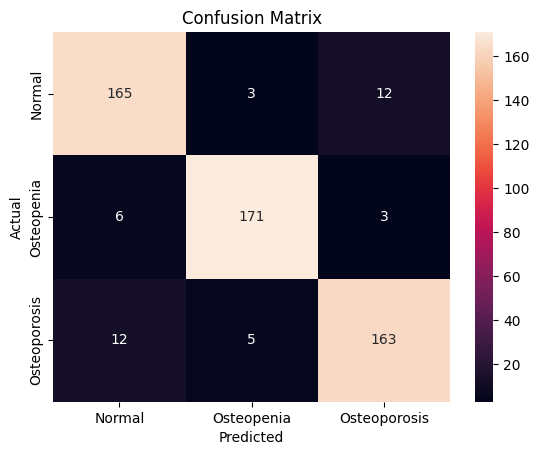

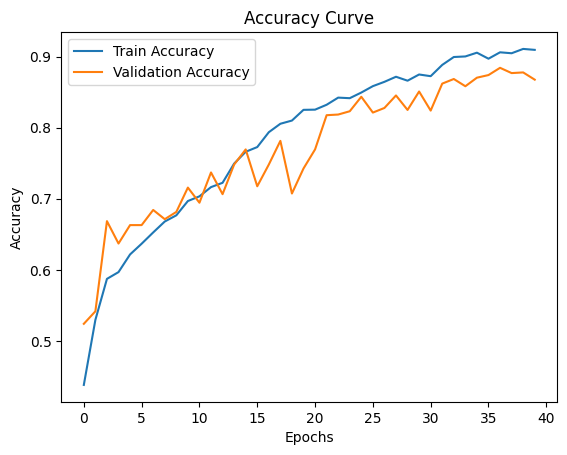

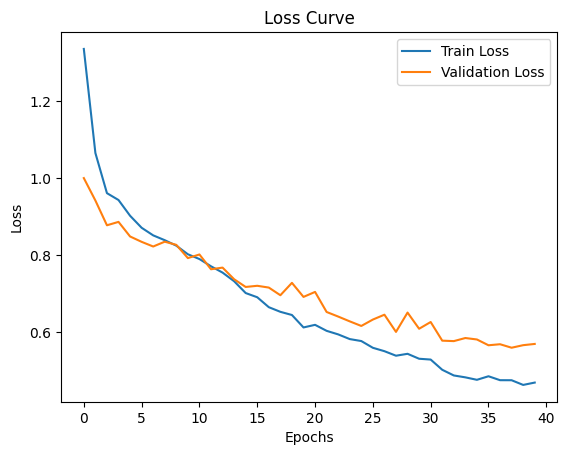

In [ ]:
# =========================
# 1. SAVE MODEL TO GOOGLE DRIVE
# =========================
model.save("/content/drive/MyDrive/knee_model.keras")
print("Model saved successfully!")

# =========================
# 2. CLASSIFICATION REPORT + CONFUSION MATRIX
# =========================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================
# 3. ACCURACY & LOSS CURVES
# =========================
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 300
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Knee Osteoarthritis Classification/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 540 images belonging to 3 classes.


Found 540 images belonging to 3 classes.
34/34 ━━━━━━━━━━━━━━━━━━━━ 1375s 40s/step


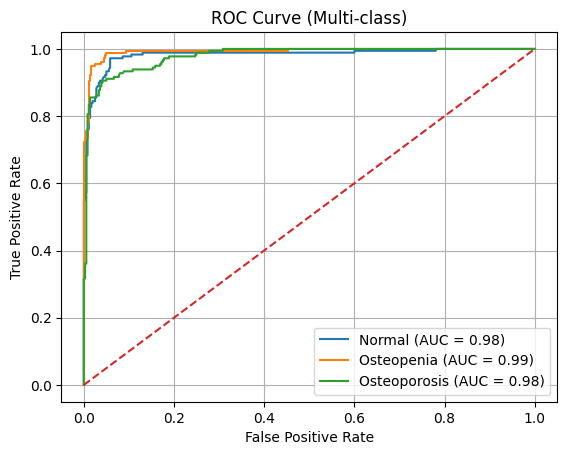

In [ ]:
# =========================
# LOAD MODEL
# =========================
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/knee_model.keras")

# =========================
# RECREATE TEST DATA
# =========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 300
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Knee Osteoarthritis Classification/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # VERY IMPORTANT
)

# =========================
# ROC CURVE
# =========================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Predictions (probabilities)
y_prob = model.predict(test_data)

# True labels
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# Convert to One-Hot
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure()

# Plot ROC for each class
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.grid()

plt.show()